In [4]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import math
import seaborn as sns
import pandas as pd
from sympy import *
from sympy import Symbol, solveset, S, erf, log, sqrt
init_printing(use_unicode=True)

import scipy.optimize as optimize

In [5]:
delta_25 = pd.read_csv('nobargaining_results_parallel_june8_delta_0.25.csv').dropna() #pd.read_csv('G_strategy_results_june3.csv').dropna()
delta_50 = pd.read_csv('nobargaining_results_parallel_june8_delta_0.5.csv').dropna() #pd.read_csv('G_strategy_results_june3.csv').dropna()
delta_75 = pd.read_csv('nobargaining_results_parallel_june8_delta_0.75.csv').dropna() #pd.read_csv('G_strategy_results_june3.csv').dropna()


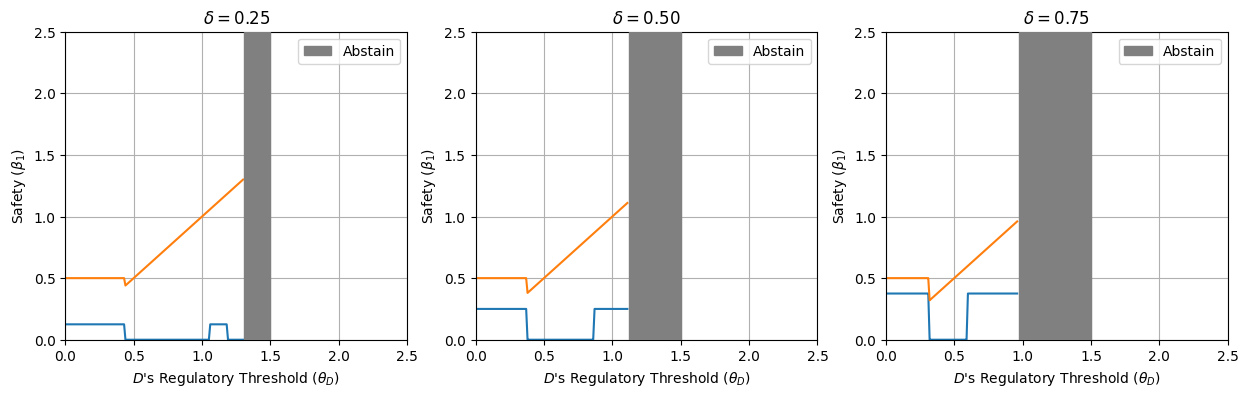

In [6]:
#sns.lineplot(data=delta_25, x='theta',y='beta_1', linewidth=0)
fig, ax = plt.subplots(1,3,figsize=[15,4])

def plot_backfiring(dataset,ax):
    sns.lineplot(data=dataset[(dataset['beta_1']>0)], x='theta', y='beta_0', ax=ax)
    sns.lineplot(data=dataset[(dataset['beta_1']>0)], x='theta', y='beta_1', ax=ax)
    ax.set_xlabel("$D$'s Regulatory Threshold ($\\theta_D$)")
    ax.set_ylabel("Safety ($\\beta_1$)")
    ax.set_xlim([0,2.5])
    ax.grid()
    ax.set_title("$\delta=%1.2f$" % dataset.loc[0,'delta'])
    # Plot a blck band for all x values where the beta_1 is negative
    # Get the theta values where beta_1 is negative
    negative_beta1_mask = dataset['beta_1'] <= 0
    negative_theta_values = dataset[negative_beta1_mask]['theta']

    if len(negative_theta_values) > 0:
        # Get the min and max theta values where beta_1 is negative
        theta_min = negative_theta_values.min()
        theta_max = negative_theta_values.max()
        
        # Add a black band (shaded region) for the range where beta_1 is negative
        ax.axvspan(theta_min, theta_max, alpha=1, color='gray', label='Abstain',zorder=10)
        ax.legend()

    ax.set_xlim([0,2.5])
    ax.set_ylim([0,2.5])

plot_backfiring(delta_25,ax[0])
plot_backfiring(delta_50,ax[1])
plot_backfiring(delta_75,ax[2])


In [51]:
delta_75

,C0,C1,r,delta,theta,thetaG,alpha_0,beta_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,backfiring_flag
0,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.75,0.00,0,0.375,0.000,0.5,0.125,0.328125,0.12500,$\beta_0=\theta_G$,unconstrained,0
1,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.75,0.01,0,0.375,0.000,0.5,0.125,0.328125,0.12500,$\beta_0=\theta_G$,unconstrained,0
2,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.75,0.02,0,0.375,0.000,0.5,0.125,0.328125,0.12500,$\beta_0=\theta_G$,unconstrained,0
3,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.75,0.03,0,0.375,0.000,0.5,0.125,0.328125,0.12500,$\beta_0=\theta_G$,unconstrained,0
4,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.75,0.04,0,0.375,0.375,0.5,0.500,0.468750,0.21875,unconstrained,unconstrained,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.75,2.46,0,-0.100,-0.100,-0.1,-0.100,-0.100000,-0.10000,abstain,abstain,1
247,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.75,2.47,0,-0.100,-0.100,-0.1,-0.100,-0.100000,-0.10000,abstain,abstain,1
248,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.75,2.48,0,-0.100,-0.100,-0.1,-0.100,-0.100000,-0.10000,abstain,abstain,1
249,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.75,2.49,0,-0.100,-0.100,-0.1,-0.100,-0.100000,-0.10000,abstain,abstain,1
